# 🔍 Ультимативный EDA: От чистки данных до бизнес-инсайтов

**Цель:** Провести полный аудит транзакционных данных e-commerce, выявить технические аномалии и сформулировать требования для ETL-пайплайна и BI-дашборда.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/raw_data.csv', encoding='ISO-8859-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Часть 1: Технический аудит и чистка

### 1.1 Анализ пропусков
CustomerID критически важен для продуктовой аналитики (LTV, Retention).

In [11]:
null_counts = df.isnull().sum()
missing_pct = (df['CustomerID'].isnull().sum() / len(df)) * 100
print(f"Доля транзакций без CustomerID: {missing_pct:.2f}%")

Доля транзакций без CustomerID: 24.93%


### 1.2 Отрицательные значения и аномалии цен
Изучаем возвраты и подозрительно дешевые/дорогие товары.

Транзакций с Quantity < 0 (возвраты): 10624
Транзакций с UnitPrice <= 0: 2517


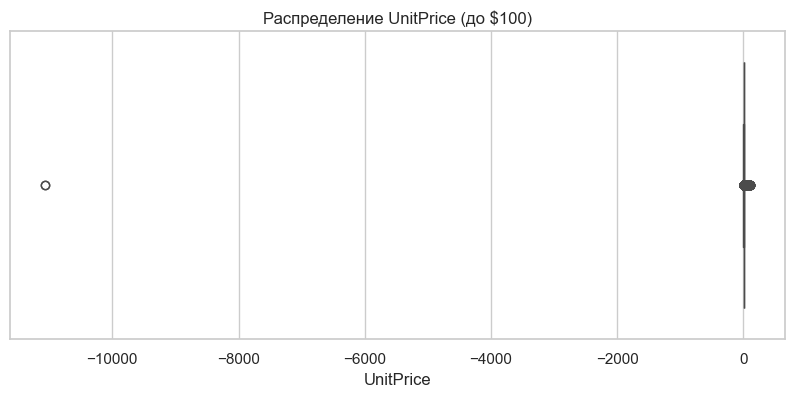

In [12]:
print(f"Транзакций с Quantity < 0 (возвраты): {len(df[df['Quantity'] < 0])}")
print(f"Транзакций с UnitPrice <= 0: {len(df[df['UnitPrice'] <= 0])}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df[df['UnitPrice'] < 100]['UnitPrice'])
plt.title("Распределение UnitPrice (до $100)")
plt.show()

## Часть 2: Проверка логики DWH

### 2.1 Временные сдвиги (Проблема отрицательного Month Index)
Проверяем, есть ли транзакции, датированные раньше официальной даты 'первой покупки' клиента.

In [13]:
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[df_clean['Quantity'] > 0]

first_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchase']

merged = df_clean.merge(first_purchase, on='CustomerID')
anomalies = merged[merged['InvoiceDate'] < merged['FirstPurchase']]
print(f"Найдено аномальных транзакций (раньше первой покупки): {len(anomalies)}")

Найдено аномальных транзакций (раньше первой покупки): 0


## Часть 3: Бизнес-исследование и инсайты

### 3.1 ABC-анализ (Принцип Парето)
Какая доля клиентов приносит основной доход?

In [14]:
customer_rev = df_clean.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).reset_index()
customer_rev['cum_pct'] = customer_rev['Revenue'].cumsum() / customer_rev['Revenue'].sum()

vip_count = customer_rev[customer_rev['cum_pct'] <= 0.8].shape[0]
print(f"80% выручки приносят {vip_count} клиентов ({vip_count/len(customer_rev):.1%})")

80% выручки приносят 1132 клиентов (26.1%)


### 3.2 Анализ нетоварных кодов (StockCode)
Ищем коды доставки, почты и комиссий.

In [15]:
service_codes = df_clean[df_clean['StockCode'].str.contains('^[a-zA-Z]+', na=False)]['StockCode'].unique()
print(f"Сервисные коды для фильтрации в ETL: {service_codes}")

Сервисные коды для фильтрации в ETL: <StringArray>
['POST', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT']
Length: 6, dtype: str


### 3.3 Активность по времени
Когда наши пользователи наиболее активны?

C:\Users\haund\AppData\Local\Temp\ipykernel_40388\2688494971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Hour', palette='viridis')


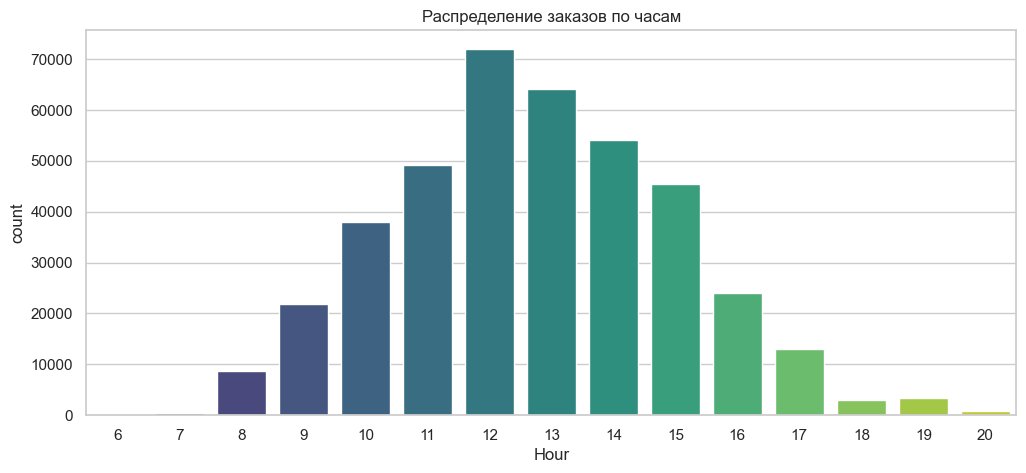

In [16]:
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
plt.figure(figsize=(12, 5))
sns.countplot(data=df_clean, x='Hour', palette='viridis')
plt.title("Распределение заказов по часам")
plt.show()

## Итоговая стратегия для продакшна:
1. **Фильтрация:** Исключаем записи без CustomerID, возвраты, UnitPrice <= 0 и сервисные коды (POST, DOT).
2. **DWH:** Внедряем строгую проверку `activity_month >= cohort_month` для корректного Retention.
3. **BI:** Добавляем RFM-сегментацию с фокусом на VIP-группу (те самые 20% клиентов).